# Bluestock Mutual Fund Capstone Project
## Day 4: Fund Performance Analytics Report


### Executive Summary & Methodology
This notebook provides a detailed performance analysis for all 40 mutual fund schemes in the Bluestock database.

#### Key Metrics & Formulas:
1. **CAGR**: $CAGR = \left(\frac{NAV_{end}}{NAV_{start}}\right)^{\frac{1}{n}} - 1$ where $n$ is the period in years.
2. **Sharpe Ratio**: $Sharpe = \frac{R_p - R_f}{\sigma_p} \times \sqrt{252}$ where $R_f = 6.5\%$ (annualized) and $\sigma_p$ is daily standard deviation.
3. **Sortino Ratio**: $Sortino = \frac{R_p - R_f}{\sigma_{down}} \times \sqrt{252}$ where $\sigma_{down}$ is the standard deviation of negative daily returns.
4. **Alpha & Beta**: Intercept and slope of OLS regression of daily returns against Nifty 100 returns. Alpha is annualized as $Alpha = Intercept \times 252$.
5. **Maximum Drawdown**: $Max\,DD = \min\left(\frac{NAV}{Running\,Max} - 1\right)$ with worst peak-to-trough range detection.
6. **Composite Scorecard**: 
   $$Score = 30\% \times Return_{3yr}\,Rank + 25\% \times Sharpe\,Rank + 20\% \times Alpha\,Rank + 15\% \times Expense\,Rank\,(inv) + 10\% \times DD\,Rank\,(inv)$$
   Scores are scaled to $0-100$ percentiles.


In [1]:
import os
import sqlite3
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio

# Set rendering format for Plotly in Jupyter
pio.renderers.default = "notebook"

# Apply premium styling configurations
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['text.color'] = '#1e293b'
plt.rcParams['axes.labelcolor'] = '#1e293b'
plt.rcParams['xtick.color'] = '#475569'
plt.rcParams['ytick.color'] = '#475569'
plt.rcParams['grid.color'] = '#e2e8f0'
plt.rcParams['grid.alpha'] = 0.8
plt.rcParams['axes.edgecolor'] = '#cbd5e1'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['figure.facecolor'] = '#f8fafc'
plt.rcParams['axes.facecolor'] = '#ffffff'
plt.rcParams['figure.figsize'] = (12, 6.5)

# Premium color palette
COLORS = ['#1e3a8a', '#0d8a72', '#e66f50', '#e6ad12', '#7c3aed', '#2563eb', '#64748b']
sns.set_palette(sns.color_palette(COLORS))

# Ensure output directories exist
os.makedirs('../reports/plots', exist_ok=True)
os.makedirs('reports/plots', exist_ok=True)
os.makedirs('../reports', exist_ok=True)
os.makedirs('reports', exist_ok=True)

# Connect to database
db_path = '../bluestock_mf.db'
if not os.path.exists(db_path):
    db_path = 'bluestock_mf.db'
    
print(f"Connecting to database: {os.path.abspath(db_path)}")
conn = sqlite3.connect(db_path)


Connecting to database: d:\bluestock_mf_capstone\bluestock_mf.db


## 1. Daily Returns Computation & Validation
We compute the daily returns for all 40 schemes: $daily\_return_t = \frac{NAV_t}{NAV_{t-1}} - 1$.
Then we validate that the distributions of daily returns look reasonable by plotting histograms/KDE and calculating descriptive statistics.


=== Descriptive Statistics of Daily Returns for 5 Sample Funds ===

Fund: HDFC Top 100 Fund - Regular Plan - Growth
  Count: 1607
  Mean: 0.000101 (Annualized: 2.5513%)
  Std Dev: 0.007749 (Annualized Volatility: 12.30%)
  Skewness: 0.1584
  Kurtosis: 1.0687

Fund: HDFC Short Term Debt Fund - Regular - Growth
  Count: 1607
  Mean: 0.000122 (Annualized: 3.0640%)
  Std Dev: 0.002081 (Annualized Volatility: 3.30%)
  Skewness: 0.0468
  Kurtosis: 1.5382

Fund: HDFC Mid-Cap Opportunities Fund - Regular - Growth
  Count: 1607
  Mean: 0.000772 (Annualized: 19.4558%)
  Std Dev: 0.010097 (Annualized Volatility: 16.03%)
  Skewness: 0.0809
  Kurtosis: 1.3036

Fund: ABSL Frontline Equity Fund - Regular - Growth
  Count: 1607
  Mean: 0.000609 (Annualized: 15.3472%)
  Std Dev: 0.007768 (Annualized Volatility: 12.33%)
  Skewness: 0.1632
  Kurtosis: 1.6014

Fund: ABSL Small Cap Fund - Regular - Growth
  Count: 1607
  Mean: 0.000303 (Annualized: 7.6478%)
  Std Dev: 0.013741 (Annualized Volatility: 21.81

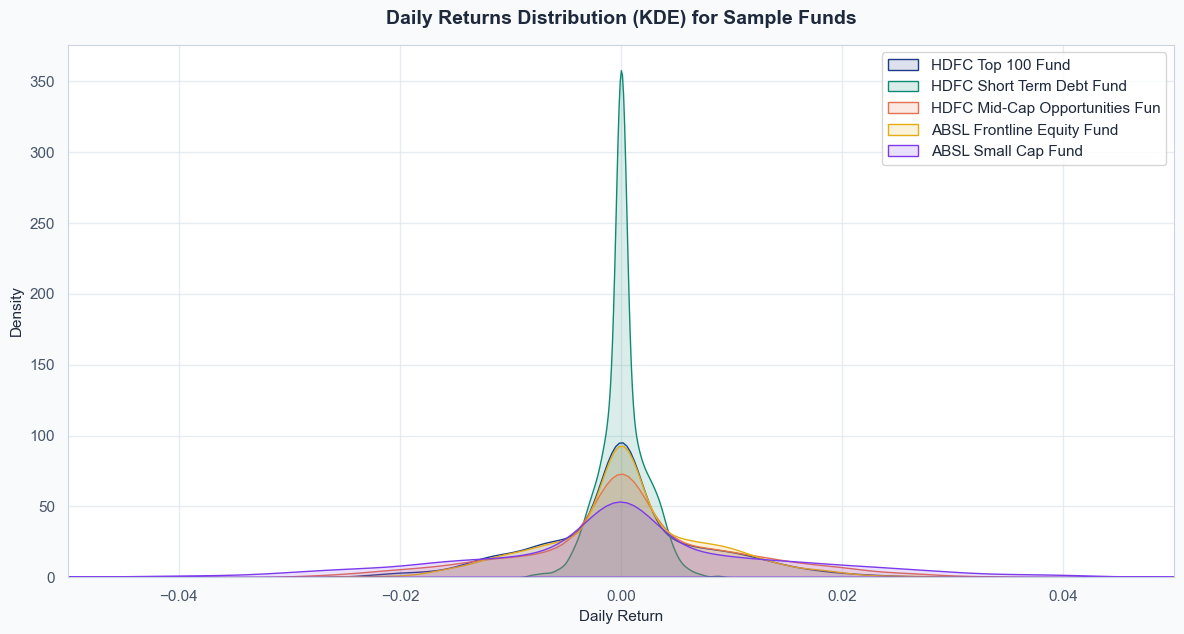

In [2]:
# Load NAV history
df_nav_raw = pd.read_sql_query("""
    SELECT n.date, n.nav, f.scheme_name, f.category, f.amfi_code
    FROM fact_nav n
    JOIN dim_fund f ON n.amfi_code = f.amfi_code
    ORDER BY f.amfi_code, n.date
""", conn)

df_nav_raw['date'] = pd.to_datetime(df_nav_raw['date'])

# Calculate daily return for each scheme
df_nav_raw['daily_return'] = df_nav_raw.groupby('amfi_code')['nav'].pct_change()

# Drop rows with NaN returns (first day of each scheme)
df_nav = df_nav_raw.dropna(subset=['daily_return']).copy()

# Descriptors for the return distributions of 5 representative funds
sample_funds = df_nav['scheme_name'].unique()[:5]
print("=== Descriptive Statistics of Daily Returns for 5 Sample Funds ===")
for fund in sample_funds:
    subset = df_nav[df_nav['scheme_name'] == fund]['daily_return']
    print(f"\nFund: {fund}")
    print(f"  Count: {len(subset)}")
    print(f"  Mean: {subset.mean():.6f} (Annualized: {subset.mean()*252:.4%})")
    print(f"  Std Dev: {subset.std():.6f} (Annualized Volatility: {subset.std()*np.sqrt(252):.2%})")
    print(f"  Skewness: {subset.skew():.4f}")
    print(f"  Kurtosis: {subset.kurtosis():.4f}")

# Plot Return Distribution for Sample Funds
plt.figure(figsize=(12, 6.5))
for fund in sample_funds:
    subset = df_nav[df_nav['scheme_name'] == fund]
    sns.kdeplot(subset['daily_return'], label=fund.split(' - ')[0][:30], fill=True, alpha=0.15)
plt.title('Daily Returns Distribution (KDE) for Sample Funds', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Daily Return', fontsize=11)
plt.ylabel('Density', fontsize=11)
plt.legend(frameon=True, facecolor='#ffffff')
plt.xlim(-0.05, 0.05)
plt.tight_layout()
plt.savefig('reports/plots/01_daily_returns_kde.png', dpi=300)
plt.savefig('../reports/plots/01_daily_returns_kde.png', dpi=300)
plt.show()


## 2. CAGR Returns (1-Year, 3-Year, and Inception-to-Date)
We compute CAGR returns using the formula: $CAGR = \left(\frac{NAV_{end}}{NAV_{start}}\right)^{\frac{1}{n}} - 1$.
- **1-Year CAGR**: Starting from the closest date to `2025-05-29` to `2026-05-29` ($n = 1$ year).
- **3-Year CAGR**: Starting from the closest date to `2023-05-29` to `2026-05-29` ($n = 3$ years).
- **5-Year (Max Available) CAGR**: From the earliest available date for each scheme in `fact_nav` (typically `2022-01-03`) to `2026-05-29`. The exact $n$ will be calculated based on the day difference.


In [3]:
latest_date = df_nav['date'].max() # 2026-05-29
target_1yr = pd.to_datetime('2025-05-29')
target_3yr = pd.to_datetime('2023-05-29')

# Helper function to find closest available date in the dataset
available_dates = df_nav['date'].unique()

def get_closest_date(target):
    diffs = np.abs(pd.to_datetime(available_dates) - pd.to_datetime(target))
    return pd.to_datetime(available_dates[diffs.argmin()])

closest_1yr = get_closest_date(target_1yr)
closest_3yr = get_closest_date(target_3yr)

print(f"CAGR Windows Configuration:")
print(f"  Latest Date: {latest_date.strftime('%Y-%m-%d')}")
print(f"  1-Year Start: {closest_1yr.strftime('%Y-%m-%d')} (target: {target_1yr.strftime('%Y-%m-%d')})")
print(f"  3-Year Start: {closest_3yr.strftime('%Y-%m-%d')} (target: {target_3yr.strftime('%Y-%m-%d')})")

# Calculate CAGR for all funds
cagr_records = []

for amfi_code in df_nav_raw['amfi_code'].unique():
    fund_data = df_nav_raw[df_nav_raw['amfi_code'] == amfi_code].sort_values('date')
    scheme_name = fund_data['scheme_name'].iloc[0]
    category = fund_data['category'].iloc[0]
    
    # NAV end (Latest available)
    nav_end_row = fund_data[fund_data['date'] == latest_date]
    if nav_end_row.empty:
        continue
    nav_end = nav_end_row['nav'].values[0]
    
    # 1-Year
    nav_1yr_row = fund_data[fund_data['date'] == closest_1yr]
    cagr_1yr = np.nan
    if not nav_1yr_row.empty:
        nav_start_1yr = nav_1yr_row['nav'].values[0]
        n_years = (latest_date - closest_1yr).days / 365.25
        cagr_1yr = (nav_end / nav_start_1yr) ** (1 / n_years) - 1
        
    # 3-Year
    nav_3yr_row = fund_data[fund_data['date'] == closest_3yr]
    cagr_3yr = np.nan
    if not nav_3yr_row.empty:
        nav_start_3yr = nav_3yr_row['nav'].values[0]
        n_years = (latest_date - closest_3yr).days / 365.25
        cagr_3yr = (nav_end / nav_start_3yr) ** (1 / n_years) - 1
        
    # Inception-to-Date (representing 5-Year CAGR / Max Available)
    earliest_date = fund_data['date'].min()
    nav_start_inc = fund_data[fund_data['date'] == earliest_date]['nav'].values[0]
    n_years_inc = (latest_date - earliest_date).days / 365.25
    cagr_5yr = (nav_end / nav_start_inc) ** (1 / n_years_inc) - 1
    
    cagr_records.append({
        'amfi_code': amfi_code,
        'scheme_name': scheme_name,
        'category': category,
        'cagr_1yr': cagr_1yr,
        'cagr_3yr': cagr_3yr,
        'cagr_5yr': cagr_5yr,
        'earliest_date': earliest_date
    })

df_cagr = pd.DataFrame(cagr_records)
print("\n=== CAGR Return Summary (Top 5 Funds by 3-Year CAGR) ===")
print(df_cagr.sort_values('cagr_3yr', ascending=False)[['scheme_name', 'cagr_1yr', 'cagr_3yr', 'cagr_5yr']].head(5))


CAGR Windows Configuration:
  Latest Date: 2026-05-29
  1-Year Start: 2025-05-29 (target: 2025-05-29)
  3-Year Start: 2023-05-29 (target: 2023-05-29)

=== CAGR Return Summary (Top 5 Funds by 3-Year CAGR) ===
                                          scheme_name  cagr_1yr  cagr_3yr  \
16                Axis Midcap Fund - Regular - Growth  0.222779  0.351025   
34      Mirae Asset Large Cap Fund - Regular - Growth  0.203760  0.339920   
24          ICICI Pru Bluechip Fund - Direct - Growth  0.130738  0.324789   
2   HDFC Mid-Cap Opportunities Fund - Regular - Gr...  0.532772  0.324340   
25           ICICI Pru Midcap Fund - Regular - Growth  0.296277  0.317692   

    cagr_5yr  
16  0.282144  
34  0.309741  
24  0.232951  
2   0.301232  
25  0.328274  


## 3. Sharpe & Sortino Ratios (Annualized)
We compute the risk-adjusted returns:
- **Sharpe Ratio** $= \frac{R_p - R_f}{\sigma_p} \times \sqrt{252}$ where $R_f = 6.5\%$ and $\sigma_p$ is daily return std dev.
- **Sortino Ratio** $= \frac{R_p - R_f}{\sigma_{down}} \times \sqrt{252}$ where $\sigma_{down}$ is downside standard deviation (std dev of negative returns relative to $R_f\,\text{daily}$).


In [4]:
rf_annual = 0.065
rf_daily = rf_annual / 252

risk_adjusted_records = []

for amfi_code in df_nav['amfi_code'].unique():
    subset = df_nav[df_nav['amfi_code'] == amfi_code].sort_values('date')
    returns = subset['daily_return'].values
    
    # Calculate Sharpe
    mean_ret = np.mean(returns)
    std_ret = np.std(returns)
    
    # Annualized Sharpe (standard formulation)
    sharpe_ann = np.nan
    if std_ret > 0:
        sharpe_ann = ((mean_ret * 252) - rf_annual) / (std_ret * np.sqrt(252))
        
    # Calculate Downside Deviation for Sortino
    # We find negative returns relative to risk free rate
    excess_returns = returns - rf_daily
    downside_excess = np.minimum(0, excess_returns)
    downside_var = np.mean(downside_excess ** 2)
    downside_std = np.sqrt(downside_var)
    
    # Annualized Sortino
    sortino_ann = np.nan
    if downside_std > 0:
        sortino_ann = ((mean_ret * 252) - rf_annual) / (downside_std * np.sqrt(252))
        
    risk_adjusted_records.append({
        'amfi_code': amfi_code,
        'sharpe_ratio': sharpe_ann,
        'sortino_ratio': sortino_ann,
        'mean_daily_return': mean_ret,
        'volatility_daily': std_ret,
        'volatility_annual': std_ret * np.sqrt(252)
    })

df_risk_adj = pd.DataFrame(risk_adjusted_records)
print("=== Sharpe & Sortino Summary (Top 5 by Sharpe Ratio) ===")
df_risk_joined = df_risk_adj.merge(df_cagr[['amfi_code', 'scheme_name']], on='amfi_code')
print(df_risk_joined.sort_values('sharpe_ratio', ascending=False)[['scheme_name', 'sharpe_ratio', 'sortino_ratio']].head(5))


=== Sharpe & Sortino Summary (Top 5 by Sharpe Ratio) ===
                                      scheme_name  sharpe_ratio  sortino_ratio
34  Mirae Asset Large Cap Fund - Regular - Growth      1.068556       1.608816
30         Kotak Flexicap Fund - Regular - Growth      0.965861       1.491261
36  Mirae Asset Tax Saver Fund - Regular - Growth      0.919333       1.397020
25       ICICI Pru Midcap Fund - Regular - Growth      0.883531       1.336129
19      SBI Bluechip Fund - Regular Plan - Growth      0.861245       1.312656


## 4. Alpha & Beta (OLS Regression against Nifty 100)
We regress daily fund returns on daily Nifty 100 returns using `scipy.stats.linregress`.
- **Beta**: Slope of OLS regression.
- **Alpha**: Annualized intercept: $Alpha = Intercept \times 252$.


In [5]:
# Load Nifty 100 benchmark index prices
df_nifty100 = pd.read_sql_query("""
    SELECT date, close_value as nifty_close
    FROM fact_benchmark_indices
    WHERE index_name = 'NIFTY100'
    ORDER BY date
""", conn)

df_nifty100['date'] = pd.to_datetime(df_nifty100['date'])
df_nifty100['nifty_return'] = df_nifty100['nifty_close'].pct_change()
df_nifty100 = df_nifty100.dropna(subset=['nifty_return']).copy()

alpha_beta_records = []

for amfi_code in df_nav['amfi_code'].unique():
    subset = df_nav[df_nav['amfi_code'] == amfi_code].sort_values('date')
    
    # Align returns on date
    merged = pd.merge(subset[['date', 'daily_return']], df_nifty100[['date', 'nifty_return']], on='date').dropna()
    
    if len(merged) < 30: # Ensure sufficient data points
        continue
        
    x = merged['nifty_return'].values
    y = merged['daily_return'].values
    
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    beta = slope
    daily_alpha = intercept
    alpha_annual = intercept * 252
    r_squared = r_value ** 2
    
    alpha_beta_records.append({
        'amfi_code': amfi_code,
        'scheme_name': subset['scheme_name'].iloc[0],
        'beta': beta,
        'daily_alpha_intercept': daily_alpha,
        'annualized_alpha': alpha_annual,
        'r_squared': r_squared,
        'p_value': p_value
    })

df_alpha_beta = pd.DataFrame(alpha_beta_records)

# Save to alpha_beta.csv
df_alpha_beta.to_csv('reports/alpha_beta.csv', index=False)
df_alpha_beta.to_csv('../reports/alpha_beta.csv', index=False)
print("Successfully generated and saved reports/alpha_beta.csv!")

print("\n=== Alpha & Beta Summary (Top 5 by Alpha) ===")
print(df_alpha_beta.sort_values('annualized_alpha', ascending=False)[['scheme_name', 'beta', 'annualized_alpha', 'r_squared']].head(5))


Successfully generated and saved reports/alpha_beta.csv!

=== Alpha & Beta Summary (Top 5 by Alpha) ===
                                      scheme_name      beta  annualized_alpha  \
21     SBI Small Cap Fund - Regular Plan - Growth -0.023196          0.303370   
39          DSP Small Cap Fund - Regular - Growth  0.011455          0.300579   
25       ICICI Pru Midcap Fund - Regular - Growth  0.000549          0.292636   
36  Mirae Asset Tax Saver Fund - Regular - Growth  0.018134          0.282704   
30         Kotak Flexicap Fund - Regular - Growth -0.022830          0.273305   

       r_squared  
21  1.414258e-04  
39  3.532991e-05  
25  1.345534e-07  
36  1.748889e-04  
30  3.430543e-04  


## 5. Maximum Drawdown & Drawdown Periods
We compute the Maximum Drawdown for each scheme: $Drawdown_t = \frac{NAV_t}{\max_{i \le t} NAV_i} - 1$.
We also identify the **Worst Drawdown Date Range** (Peak Date, Trough Date, Recovery Date) and the recovery duration.


In [6]:
drawdown_records = []

for amfi_code in df_nav_raw['amfi_code'].unique():
    fund_data = df_nav_raw[df_nav_raw['amfi_code'] == amfi_code].sort_values('date').copy()
    fund_data.set_index('date', inplace=True)
    
    nav = fund_data['nav']
    running_max = nav.cummax()
    drawdowns = nav / running_max - 1
    max_dd = drawdowns.min()
    
    # Worst drawdown dates calculation
    trough_date = drawdowns.idxmin()
    # Find peak before trough
    nav_before_trough = nav.loc[:trough_date]
    running_max_before_trough = running_max.loc[:trough_date]
    peak_date = nav_before_trough[nav_before_trough == running_max_before_trough].index[-1]
    
    # Find recovery date
    nav_peak_val = nav.loc[peak_date]
    recovery_slice = nav.loc[trough_date:]
    recovery_matches = recovery_slice[recovery_slice >= nav_peak_val]
    
    if not recovery_matches.empty:
        recovery_date = recovery_matches.index[0]
        recovery_duration = (recovery_date - peak_date).days
        recovery_str = recovery_date.strftime('%Y-%m-%d')
    else:
        recovery_date = np.nan
        recovery_duration = np.nan
        recovery_str = "Unrecovered"
        
    drawdown_records.append({
        'amfi_code': amfi_code,
        'max_drawdown': max_dd,
        'peak_date': peak_date.strftime('%Y-%m-%d'),
        'trough_date': trough_date.strftime('%Y-%m-%d'),
        'recovery_date': recovery_str,
        'recovery_duration_days': recovery_duration
    })

df_drawdowns = pd.DataFrame(drawdown_records)
print("=== Maximum Drawdown Summary (Worst 5 Funds by Max Drawdown) ===")
df_dd_joined = df_drawdowns.merge(df_cagr[['amfi_code', 'scheme_name']], on='amfi_code')
print(df_dd_joined.sort_values('max_drawdown', ascending=True)[['scheme_name', 'max_drawdown', 'peak_date', 'trough_date', 'recovery_date']].head(5))


=== Maximum Drawdown Summary (Worst 5 Funds by Max Drawdown) ===
                                   scheme_name  max_drawdown   peak_date  \
22   SBI Small Cap Fund - Direct Plan - Growth     -0.525742  2023-01-17   
17      Axis Small Cap Fund - Regular - Growth     -0.516778  2025-05-22   
4       ABSL Small Cap Fund - Regular - Growth     -0.354469  2024-11-21   
39       DSP Small Cap Fund - Regular - Growth     -0.311719  2024-05-05   
21  SBI Small Cap Fund - Regular Plan - Growth     -0.287060  2024-08-28   

   trough_date recovery_date  
22  2025-10-28   Unrecovered  
17  2026-05-11   Unrecovered  
4   2026-05-11   Unrecovered  
39  2025-01-03    2025-06-13  
21  2025-05-14    2025-09-29  


## 6. Composite Fund Scorecard
We build a composite score (0-100) using percentile ranks:
- **3-Year Return Rank**: weight = 30%
- **Sharpe Ratio Rank**: weight = 25%
- **Alpha Rank**: weight = 20%
- **Expense Ratio Rank (Inverse)**: weight = 15% (lower expense is better)
- **Max DD Rank (Inverse)**: weight = 10% (smaller drawdown magnitude is better, i.e., closer to 0)

All scores are weighted and sorted to rank all 40 funds.


In [7]:
# Retrieve expense ratios from dim_fund
df_exp_ratio = pd.read_sql_query("SELECT amfi_code, expense_ratio_pct FROM dim_fund", conn)

# Merge all metrics
df_merged = df_cagr.merge(df_risk_adj, on='amfi_code') \
                   .merge(df_alpha_beta[['amfi_code', 'beta', 'annualized_alpha', 'r_squared']], on='amfi_code') \
                   .merge(df_drawdowns, on='amfi_code') \
                   .merge(df_exp_ratio, on='amfi_code')

# Compute Percentile Ranks (0 to 100)
df_merged['rank_return'] = df_merged['cagr_3yr'].rank(pct=True) * 100
df_merged['rank_sharpe'] = df_merged['sharpe_ratio'].rank(pct=True) * 100
df_merged['rank_alpha'] = df_merged['annualized_alpha'].rank(pct=True) * 100
# Expense Ratio (lower is better, ascending=False)
df_merged['rank_expense_inv'] = df_merged['expense_ratio_pct'].rank(ascending=False, pct=True) * 100
# Max Drawdown (algebraically larger/closer to 0 is better, ascending=True)
df_merged['rank_max_dd_inv'] = df_merged['max_drawdown'].rank(ascending=True, pct=True) * 100

# Calculate Composite Score
df_merged['composite_score'] = (
    0.30 * df_merged['rank_return'] +
    0.25 * df_merged['rank_sharpe'] +
    0.20 * df_merged['rank_alpha'] +
    0.15 * df_merged['rank_expense_inv'] +
    0.10 * df_merged['rank_max_dd_inv']
)

# Sort and assign overall rank (1 to 40)
df_merged = df_merged.sort_values('composite_score', ascending=False).copy()
df_merged['rank'] = range(1, len(df_merged) + 1)

# Reorder columns for clean delivery
final_cols = [
    'rank', 'amfi_code', 'scheme_name', 'category', 'cagr_1yr', 'cagr_3yr', 'cagr_5yr',
    'sharpe_ratio', 'sortino_ratio', 'annualized_alpha', 'beta', 'max_drawdown',
    'expense_ratio_pct', 'composite_score', 'peak_date', 'trough_date', 'recovery_date'
]
df_scorecard = df_merged[final_cols].copy()

# Save to fund_scorecard.csv
df_scorecard.to_csv('reports/fund_scorecard.csv', index=False)
df_scorecard.to_csv('../reports/fund_scorecard.csv', index=False)
print("Successfully generated and saved reports/fund_scorecard.csv!")

print("\n=== Top 5 Scorecard Funds ===")
print(df_scorecard[['rank', 'scheme_name', 'category', 'cagr_3yr', 'sharpe_ratio', 'composite_score']].head(5))


Successfully generated and saved reports/fund_scorecard.csv!

=== Top 5 Scorecard Funds ===
    rank                                        scheme_name category  \
34     1      Mirae Asset Large Cap Fund - Regular - Growth   Equity   
25     2           ICICI Pru Midcap Fund - Regular - Growth   Equity   
30     3             Kotak Flexicap Fund - Regular - Growth   Equity   
2      4  HDFC Mid-Cap Opportunities Fund - Regular - Gr...   Equity   
24     5          ICICI Pru Bluechip Fund - Direct - Growth   Equity   

    cagr_3yr  sharpe_ratio  composite_score  
34  0.339920      1.068556           86.250  
25  0.317692      0.883531           82.875  
30  0.295751      0.965861           82.000  
2   0.324340      0.808519           80.750  
24  0.324789      0.714905           79.375  


## 7. Tracking Error & Benchmark Comparison (Last 3 Years)
We extract the **Top 5 Funds** based on the scorecard score.
We plot their normalized performance (starting from 100) vs the **Nifty 50** and **Nifty 100** benchmark indices over the last 3 years (May 2023 - May 2026).
We also compute the **annualized tracking error** for each of these top 5 funds relative to the Nifty 100:
$\text{Tracking Error} = \sigma(R_{fund} - R_{bench}) \times \sqrt{252}$.


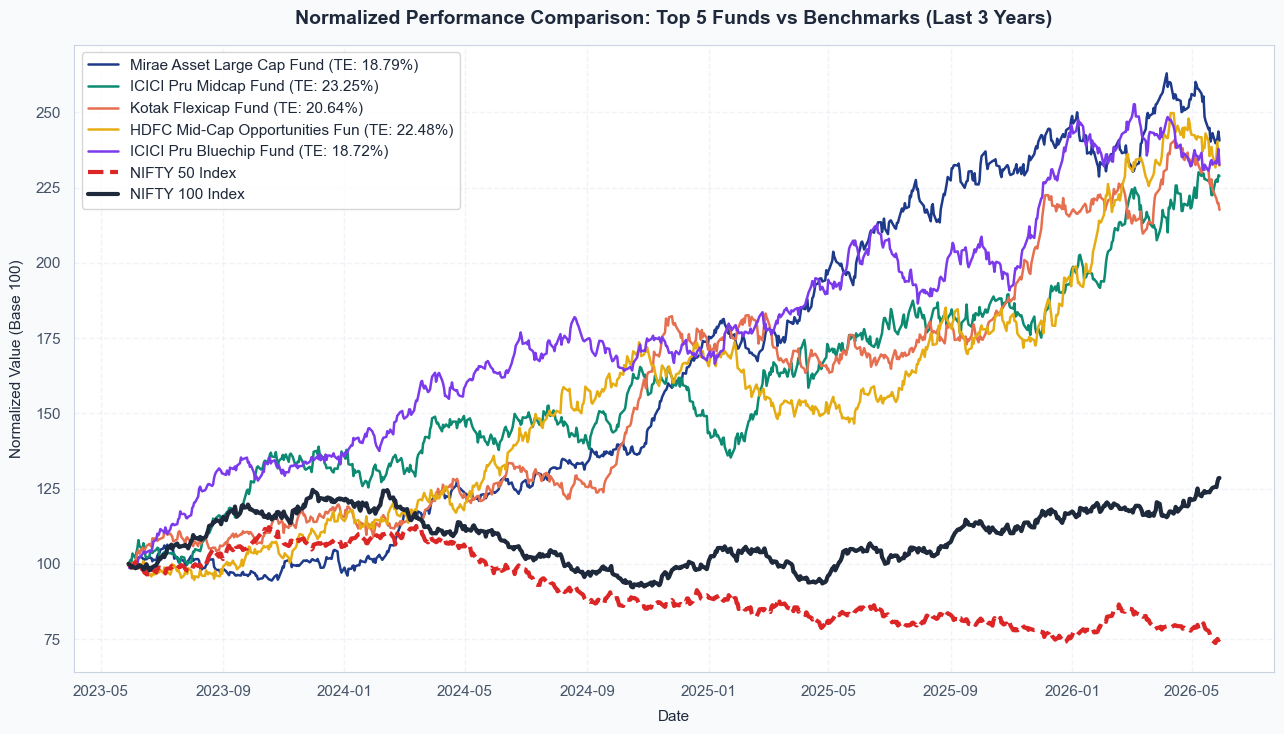

In [8]:
top_5_amfi = df_scorecard['amfi_code'].head(5).tolist()
top_5_names = df_scorecard['scheme_name'].head(5).tolist()

# Query NAV for top 5 funds
df_top_nav = pd.read_sql_query(f"""
    SELECT date, nav, amfi_code
    FROM fact_nav
    WHERE amfi_code IN ({','.join(map(str, top_5_amfi))})
      AND date >= '2023-05-29'
    ORDER BY date
""", conn)

df_top_nav['date'] = pd.to_datetime(df_top_nav['date'])

# Query Benchmarks (NIFTY50 & NIFTY100)
df_benchmarks = pd.read_sql_query("""
    SELECT date, index_name, close_value
    FROM fact_benchmark_indices
    WHERE index_name IN ('NIFTY50', 'NIFTY100')
      AND date >= '2023-05-29'
    ORDER BY date
""", conn)

df_benchmarks['date'] = pd.to_datetime(df_benchmarks['date'])

# Pivot data to align dates
df_funds_pivot = df_top_nav.pivot(index='date', columns='amfi_code', values='nav')
df_bench_pivot = df_benchmarks.pivot(index='date', columns='index_name', values='close_value')

# Combine and drop rows where any are NaN to align perfectly
df_aligned = pd.concat([df_funds_pivot, df_bench_pivot], axis=1).dropna()

# Normalize to 100 at start
df_normalized = (df_aligned / df_aligned.iloc[0]) * 100

# Compute daily returns for Tracking Error against NIFTY100
df_returns_aligned = df_aligned.pct_change().dropna()

tracking_errors = {}
for code in top_5_amfi:
    name = df_scorecard[df_scorecard['amfi_code'] == code]['scheme_name'].values[0]
    fund_ret = df_returns_aligned[code]
    nifty_ret = df_returns_aligned['NIFTY100']
    
    diff = fund_ret - nifty_ret
    tracking_err_ann = np.std(diff) * np.sqrt(252)
    tracking_errors[code] = tracking_err_ann

# Plot normalized performance
plt.figure(figsize=(13, 7.5))

# Plot top 5 funds
for code in top_5_amfi:
    name_short = df_scorecard[df_scorecard['amfi_code'] == code]['scheme_name'].values[0].split(' - ')[0][:30]
    te_pct = tracking_errors[code] * 100
    plt.plot(df_normalized.index, df_normalized[code], label=f"{name_short} (TE: {te_pct:.2f}%)", linewidth=1.8)

# Plot Nifty 50 and Nifty 100 with thicker lines
plt.plot(df_normalized.index, df_normalized['NIFTY50'], label='NIFTY 50 Index', linewidth=3.0, linestyle='--', color='#dc2626')
plt.plot(df_normalized.index, df_normalized['NIFTY100'], label='NIFTY 100 Index', linewidth=3.0, linestyle='-', color='#1e293b')

plt.title('Normalized Performance Comparison: Top 5 Funds vs Benchmarks (Last 3 Years)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=11, labelpad=8)
plt.ylabel('Normalized Value (Base 100)', fontsize=11, labelpad=8)
plt.legend(loc='upper left', frameon=True, facecolor='#ffffff')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig('reports/plots/benchmark_comparison_chart.png', dpi=300)
plt.savefig('../reports/plots/benchmark_comparison_chart.png', dpi=300)
plt.show()


In [9]:
# Close connection
conn.close()
print("Database connection closed. Performance analytics complete.")


Database connection closed. Performance analytics complete.
